# EDA & Data Loading

In [5]:
# important packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# assinging data and checking loaded properly
DATA_DIR = '../data/raw/'
print('Files available:')
files = sorted(os.listdir(DATA_DIR))
for f in files:
    print(' ', f)

Files available:
  Cities.csv
  Conferences.csv
  MConferenceTourneyGames.csv
  MGameCities.csv
  MMasseyOrdinals.csv
  MNCAATourneyCompactResults.csv
  MNCAATourneyDetailedResults.csv
  MNCAATourneySeedRoundSlots.csv
  MNCAATourneySeeds.csv
  MNCAATourneySlots.csv
  MRegularSeasonCompactResults.csv
  MRegularSeasonDetailedResults.csv
  MSeasons.csv
  MSecondaryTourneyCompactResults.csv
  MSecondaryTourneyTeams.csv
  MTeamCoaches.csv
  MTeamConferences.csv
  MTeamSpellings.csv
  MTeams.csv
  SampleSubmissionStage1.csv
  SampleSubmissionStage2.csv
  WConferenceTourneyGames.csv
  WGameCities.csv
  WNCAATourneyCompactResults.csv
  WNCAATourneyDetailedResults.csv
  WNCAATourneySeeds.csv
  WNCAATourneySlots.csv
  WRegularSeasonCompactResults.csv
  WRegularSeasonDetailedResults.csv
  WSeasons.csv
  WSecondaryTourneyCompactResults.csv
  WSecondaryTourneyTeams.csv
  WTeamConferences.csv
  WTeamSpellings.csv
  WTeams.csv


## Load Core Files

In [6]:
# --- Teams ---
m_teams = pd.read_csv(DATA_DIR + 'MTeams.csv')
w_teams = pd.read_csv(DATA_DIR + 'WTeams.csv')
print(f"Men's teams: {len(m_teams)} | Women's teams: {len(w_teams)}")
m_teams.head()

Men's teams: 381 | Women's teams: 379


,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026


In [7]:
# --- Seeds ---
m_seeds = pd.read_csv(DATA_DIR + 'MNCAATourneySeeds.csv')
w_seeds = pd.read_csv(DATA_DIR + 'WNCAATourneySeeds.csv')

# Parse numeric seed from string like 'W01', 'X16a'
def parse_seed(s):
    return int(''.join(filter(str.isdigit, s)))

m_seeds['SeedNum'] = m_seeds['Seed'].apply(parse_seed)
w_seeds['SeedNum'] = w_seeds['Seed'].apply(parse_seed)

print(f"Men's seeds shape: {m_seeds.shape}")
print(f"Seasons covered: {m_seeds['Season'].min()} - {m_seeds['Season'].max()}")
m_seeds.head(10)

Men's seeds shape: (2626, 4)
Seasons covered: 1985 - 2025


,Season,Seed,TeamID,SeedNum
0,1985,W01,1207,1
1,1985,W02,1210,2
2,1985,W03,1228,3
3,1985,W04,1260,4
4,1985,W05,1374,5
5,1985,W06,1208,6
6,1985,W07,1393,7
7,1985,W08,1396,8
8,1985,W09,1439,9
9,1985,W10,1177,10


In [10]:
# --- Regular Season Detailed Results ---
m_reg = pd.read_csv(DATA_DIR + 'MRegularSeasonDetailedResults.csv')
w_reg = pd.read_csv(DATA_DIR + 'WRegularSeasonDetailedResults.csv')

print(f"Men's regular season games: {len(m_reg)}")
print(f"Seasons: {m_reg['Season'].min()} - {m_reg['Season'].max()}")
print(m_reg.columns)
m_reg.head(3)

Men's regular season games: 124031
Seasons: 2003 - 2026
Index(['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',
       'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR',
       'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3',
       'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF'],
      dtype='str')


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23


In [11]:
# --- Tournament Results ---
m_tourney = pd.read_csv(DATA_DIR + 'MNCAATourneyDetailedResults.csv')
w_tourney = pd.read_csv(DATA_DIR + 'WNCAATourneyDetailedResults.csv')

print(f"Men's tourney games: {len(m_tourney)}")
print(f"Seasons: {m_tourney['Season'].min()} - {m_tourney['Season'].max()}")
m_tourney.head(3)

Men's tourney games: 1449
Seasons: 2003 - 2025


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,...,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,...,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,...,28,14,21,20,22,11,12,2,5,18


In [12]:
# --- Massey Ordinals (External Rankings) ---
m_massey = pd.read_csv(DATA_DIR + 'MMasseyOrdinals.csv')
print(f"Shape: {m_massey.shape}")
print(f"Systems available: {m_massey['SystemName'].nunique()}")
print("\nSample systems:")
print(m_massey['SystemName'].unique()[:20])
m_massey.head()

Shape: (5819228, 5)
Systems available: 196

Sample systems:
<StringArray>
['SEL',  'AP', 'BIH', 'DUN', 'ENT', 'GRN', 'IMS', 'MAS', 'MKV', 'MOR', 'POM',
 'RPI', 'SAG', 'SAU',  'SE', 'STR', 'USA', 'WLK', 'WOB', 'BOB']
Length: 20, dtype: str


,Season,RankingDayNum,SystemName,TeamID,OrdinalRank
0,2003,35,SEL,1102,159
1,2003,35,SEL,1103,229
2,2003,35,SEL,1104,12
3,2003,35,SEL,1105,314
4,2003,35,SEL,1106,260


In [13]:
# --- Sample Submissions ---
stage1 = pd.read_csv(DATA_DIR + 'SampleSubmissionStage1.csv')
stage2 = pd.read_csv(DATA_DIR + 'SampleSubmissionStage2.csv')

print(f"Stage 1 rows (2022-2025 validation): {len(stage1)}")
print(f"Stage 2 rows (2026 actual submission): {len(stage2)}")
print("\nFormat example:")
stage2.head()

Stage 1 rows (2022-2025 validation): 519144
Stage 2 rows (2026 actual submission): 132133

Format example:


,ID,Pred
0,2026_1101_1102,0.5
1,2026_1101_1103,0.5
2,2026_1101_1104,0.5
3,2026_1101_1105,0.5
4,2026_1101_1106,0.5


## Explore Detailed Game Stats Columns
These are the box score columns we have available for feature engineering.

In [14]:
print("Columns in MRegularSeasonDetailedResults:")
for col in m_reg.columns:
    print(f"  {col}")

Columns in MRegularSeasonDetailedResults:
  Season
  DayNum
  WTeamID
  WScore
  LTeamID
  LScore
  WLoc
  NumOT
  WFGM
  WFGA
  WFGM3
  WFGA3
  WFTM
  WFTA
  WOR
  WDR
  WAst
  WTO
  WStl
  WBlk
  WPF
  LFGM
  LFGA
  LFGM3
  LFGA3
  LFTM
  LFTA
  LOR
  LDR
  LAst
  LTO
  LStl
  LBlk
  LPF


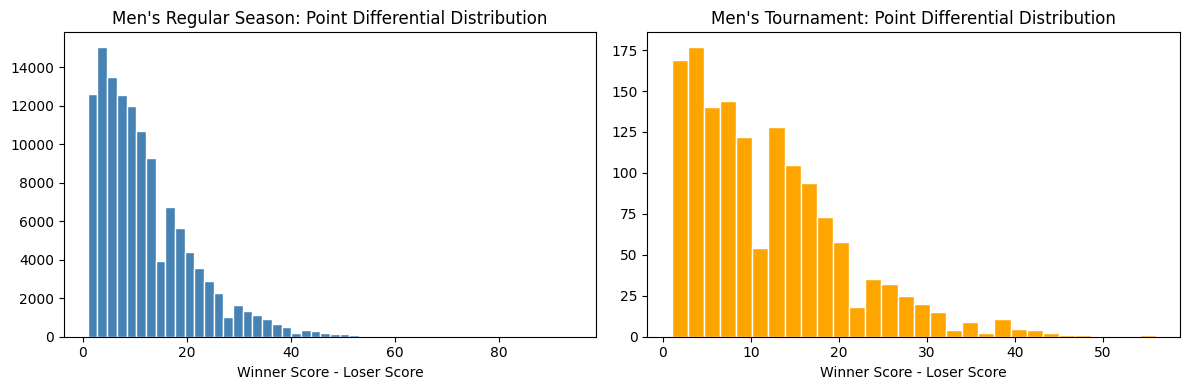

In [15]:
# Basic distributions of winning scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(m_reg['WScore'] - m_reg['LScore'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Men's Regular Season: Point Differential Distribution")
axes[0].set_xlabel('Winner Score - Loser Score')

axes[1].hist(m_tourney['WScore'] - m_tourney['LScore'], bins=30, color='orange', edgecolor='white')
axes[1].set_title("Men's Tournament: Point Differential Distribution")
axes[1].set_xlabel('Winner Score - Loser Score')

plt.tight_layout()
plt.savefig('../outputs/score_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## Seed vs Outcome Analysis
Quick look at how well seeds predict tournament outcomes historically.

In [16]:
# Merge seeds onto tourney results
m_tourney_seeds = m_tourney.merge(
    m_seeds[['Season','TeamID','SeedNum']].rename(columns={'TeamID':'WTeamID','SeedNum':'WSeed'}),
    on=['Season','WTeamID']
).merge(
    m_seeds[['Season','TeamID','SeedNum']].rename(columns={'TeamID':'LTeamID','SeedNum':'LSeed'}),
    on=['Season','LTeamID']
)

# How often does the lower seed (better team) win?
upsets = m_tourney_seeds[m_tourney_seeds['WSeed'] > m_tourney_seeds['LSeed']]
total = len(m_tourney_seeds)
print(f"Total tourney games: {total}")
print(f"Upsets (worse seed wins): {len(upsets)} ({100*len(upsets)/total:.1f}%)")
print(f"Favorites win: {total - len(upsets)} ({100*(total-len(upsets))/total:.1f}%)")

Total tourney games: 1449
Upsets (worse seed wins): 392 (27.1%)
Favorites win: 1057 (72.9%)


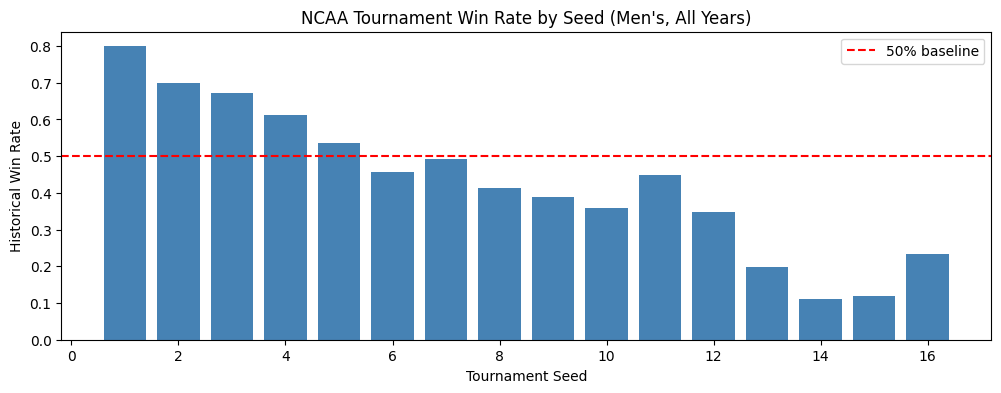

In [17]:
# Seed matchup win rates
m_tourney_seeds['SeedDiff'] = m_tourney_seeds['LSeed'] - m_tourney_seeds['WSeed']
seed_win_rates = m_tourney_seeds.groupby('WSeed').size().reset_index(name='Wins')
seed_total = pd.concat([
    m_tourney_seeds[['Season','WSeed']].rename(columns={'WSeed':'Seed'}),
    m_tourney_seeds[['Season','LSeed']].rename(columns={'LSeed':'Seed'})
]).groupby('Seed').size().reset_index(name='GamesPlayed')

seed_stats = seed_win_rates.merge(seed_total, left_on='WSeed', right_on='Seed')
seed_stats['WinRate'] = seed_stats['Wins'] / seed_stats['GamesPlayed']

plt.figure(figsize=(12, 4))
plt.bar(seed_stats['Seed'], seed_stats['WinRate'], color='steelblue')
plt.axhline(0.5, color='red', linestyle='--', label='50% baseline')
plt.xlabel('Tournament Seed')
plt.ylabel('Historical Win Rate')
plt.title("NCAA Tournament Win Rate by Seed (Men's, All Years)")
plt.legend()
plt.savefig('../outputs/seed_win_rates.png', dpi=120, bbox_inches='tight')
plt.show()